In [34]:
import os, random, time, math, copy, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

# Make paths work if VS Code starts from the course repo folder.
if os.path.basename(os.getcwd()) != 'Homework_4' and os.path.isdir('Homework_4'):
    os.chdir('Homework_4')
print('current folder:', os.getcwd())

# Safe laptop mode. Keep this True if running multiple notebooks at the same time.
parallel_cpu_mode = True
if parallel_cpu_mode and device.type == 'cpu':
    torch.set_num_threads(2)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass

results_folder = 'Results_Problem_1'
os.makedirs(results_folder, exist_ok=True)

# Quick defaults. For stronger final results later, set parallel_cpu_mode = False.
sequence_lengths = [10, 20, 30]
hidden_size = 32 if parallel_cpu_mode else 128
num_layers = 1 if parallel_cpu_mode else 2
nhead = 2 if parallel_cpu_mode else 4
dropout = 0.20
learning_rate = 0.0025
weight_decay = 1e-3
epochs = 250 if parallel_cpu_mode else 260
patience = 10 if parallel_cpu_mode else 45
clip_value = 1.0
train_batch_size = 128
val_batch_size = 256
quick_train_limit = 500 if parallel_cpu_mode else None
quick_val_limit = 150 if parallel_cpu_mode else None

print('parallel_cpu_mode:', parallel_cpu_mode)
print('torch threads:', torch.get_num_threads())
print('hidden_size:', hidden_size)
print('num_layers:', num_layers)
print('nhead:', nhead)
print('epochs:', epochs)
print('quick_train_limit:', quick_train_limit)
print('quick_val_limit:', quick_val_limit)

device: cpu
current folder: c:\Users\vipra\OneDrive\Documents\GitHub\ECGR-5106-Intro-To-Deep-Learning\Homework_4
parallel_cpu_mode: True
torch threads: 2
hidden_size: 32
num_layers: 1
nhead: 2
epochs: 250
quick_train_limit: 500
quick_val_limit: 150


In [35]:
text = """Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.

At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.

One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.

Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.

Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.

In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology."""

In [36]:
# Creating character vocabulary, same idea as Homework 2.
chars = sorted(list(set(text)))
ix_to_char = {i: ch for i, ch in enumerate(chars)}
char_to_ix = {ch: i for i, ch in enumerate(chars)}

print('Text length:', len(text))
print('Vocabulary size:', len(chars))
print('First 200 characters:')
print(text[:200])

Text length: 2391
Vocabulary size: 45
First 200 characters:
Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede


In [37]:
# Preparing the dataset like my Homework 2 file.
# The target is a shifted sequence, not just one final character.

def make_dataset(max_length):
    encoded = np.array([char_to_ix[ch] for ch in text])
    X = []
    y = []
    for i in range(len(encoded) - max_length):
        sequence = encoded[i:i + max_length]
        label_sequence = encoded[i + 1:i + max_length + 1]
        X.append(sequence)
        y.append(label_sequence)

    X = np.array(X)
    y = np.array(y)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=seed, shuffle=True)

    # In quick mode, use a fixed subset so the notebook runs fast and does not kill the kernel.
    if quick_train_limit is not None:
        X_train = X_train[:quick_train_limit]
        y_train = y_train[:quick_train_limit]
    if quick_val_limit is not None:
        X_val = X_val[:quick_val_limit]
        y_val = y_val[:quick_val_limit]

    # Keep tensors on CPU until each mini-batch is used. This avoids memory spikes.
    X_train = torch.tensor(X_train, dtype=torch.long)
    y_train = torch.tensor(y_train, dtype=torch.long)
    X_val = torch.tensor(X_val, dtype=torch.long)
    y_val = torch.tensor(y_val, dtype=torch.long)
    return X_train, X_val, y_train, y_val


def make_tensor_batches(X, y, batch_size=128, shuffle=True):
    indices = torch.randperm(X.size(0)) if shuffle else torch.arange(X.size(0))
    for start in range(0, X.size(0), batch_size):
        batch_idx = indices[start:start + batch_size]
        yield X[batch_idx].to(device), y[batch_idx].to(device)


X_train, X_val, y_train, y_val = make_dataset(10)
print('X train:', X_train.shape, 'y train:', y_train.shape)
print('X val:', X_val.shape, 'y val:', y_val.shape)

X train: torch.Size([500, 10]) y train: torch.Size([500, 10])
X val: torch.Size([150, 10]) y val: torch.Size([150, 10])


In [38]:
# Lighter Transformer block. This still uses multi-head attention, but is faster than nn.TransformerEncoder on CPU.
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        encoding = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        encoding[:, 0::2] = torch.sin(position * div_term)
        encoding[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('encoding', encoding.unsqueeze(0))

    def forward(self, x):
        return x + self.encoding[:, :x.size(1)]


class SimpleTransformerBlock(nn.Module):
    def __init__(self, hidden_size, nhead=2, dropout=0.1):
        super(SimpleTransformerBlock, self).__init__()
        self.attention = nn.MultiheadAttention(hidden_size, nhead, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(hidden_size)
        self.norm2 = nn.LayerNorm(hidden_size)
        self.ff = nn.Sequential(
            nn.Linear(hidden_size, hidden_size * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, hidden_size)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_output, _ = self.attention(x, x, x, need_weights=False)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.ff(x)
        x = self.norm2(x + self.dropout(ff_output))
        return x


class CharTransformer(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1, nhead=2, dropout=0.2):
        super(CharTransformer, self).__init__()
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.pos_encoder = PositionalEncoding(hidden_size)
        self.blocks = nn.ModuleList([SimpleTransformerBlock(hidden_size, nhead, dropout) for _ in range(num_layers)])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        output = self.embedding(x)
        output = self.pos_encoder(output)
        for block in self.blocks:
            output = block(output)
        output = self.dropout(output)
        output = self.fc(output)
        return output


def get_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_size_mb(model):
    return get_params(model) * 4 / (1024 ** 2)


def rough_complexity(seq_length, hidden_size, num_layers):
    return num_layers * ((2 * seq_length * seq_length * hidden_size) + (2 * seq_length * hidden_size * hidden_size))


def top_k_accuracy(output, target, k=3):
    _, pred = output.topk(k, dim=1)
    correct = pred.eq(target.view(-1, 1).expand_as(pred))
    return correct.any(dim=1).float().mean().item()

In [39]:
def evaluate_transformer(model, X_val, y_val, criterion):
    model.eval()
    total_loss = 0.0
    total_tokens = 0
    correct = 0
    last_correct = 0
    total_last = 0
    top3_total = 0.0
    top5_total = 0.0
    top_batches = 0

    with torch.no_grad():
        for xb, yb in make_tensor_batches(X_val, y_val, batch_size=val_batch_size, shuffle=False):
            output = model(xb)
            loss = criterion(output.reshape(-1, len(chars)), yb.reshape(-1))
            flat_output = output.reshape(-1, len(chars))
            flat_target = yb.reshape(-1)
            pred = flat_output.argmax(1)

            total_loss += loss.item() * flat_target.numel()
            total_tokens += flat_target.numel()
            correct += (pred == flat_target).sum().item()

            last_output = output[:, -1, :]
            last_target = yb[:, -1]
            last_correct += (last_output.argmax(1) == last_target).sum().item()
            total_last += last_target.numel()

            top3_total += top_k_accuracy(flat_output, flat_target, k=3)
            top5_total += top_k_accuracy(flat_output, flat_target, k=5)
            top_batches += 1

    return total_loss / total_tokens, correct / total_tokens, last_correct / total_last, top3_total / top_batches, top5_total / top_batches


def train_one_model(max_length=10):
    X_train, X_val, y_train, y_val = make_dataset(max_length)

    model = CharTransformer(
        input_size=len(chars),
        hidden_size=hidden_size,
        output_size=len(chars),
        num_layers=num_layers,
        nhead=nhead,
        dropout=dropout
    ).to(device)

    try:
        criterion = nn.CrossEntropyLoss(label_smoothing=0.03)
    except TypeError:
        criterion = nn.CrossEntropyLoss()

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-5)

    train_losses = []
    val_losses = []
    val_accs = []
    val_last_accs = []
    val_top3_accs = []
    val_top5_accs = []

    best_val_acc = 0
    best_last_acc = 0
    best_val_top3_acc = 0
    best_val_top5_acc = 0
    best_val_loss = 999
    best_epoch = 0
    best_state = copy.deepcopy(model.state_dict())
    no_improve_count = 0

    start = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_tokens = 0

        for xb, yb in make_tensor_batches(X_train, y_train, batch_size=train_batch_size, shuffle=True):
            optimizer.zero_grad()
            output = model(xb)
            loss = criterion(output.reshape(-1, len(chars)), yb.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
            optimizer.step()

            running_loss += loss.item() * yb.numel()
            running_tokens += yb.numel()

        train_loss = running_loss / running_tokens
        val_loss, val_acc, last_acc, top3, top5 = evaluate_transformer(model, X_val, y_val, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        val_last_accs.append(last_acc)
        val_top3_accs.append(top3)
        val_top5_accs.append(top5)
        scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_last_acc = last_acc
            best_val_top3_acc = top3
            best_val_top5_acc = top5
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            no_improve_count = 0
        else:
            no_improve_count += 1

        if (epoch + 1) % 5 == 0:
            print('seq', max_length, 'epoch', epoch + 1, 'train loss', round(train_loss, 4), 'val acc', round(val_acc, 4), 'top5', round(top5, 4))

        if no_improve_count >= patience:
            print('early stopping for seq', max_length, 'at epoch', epoch + 1)
            break

    training_time = time.time() - start
    model.load_state_dict(best_state)
    info = {
        'model_type': 'Transformer',
        'seq_length': max_length,
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'nhead': nhead,
        'dropout': dropout,
        'epochs_planned': epochs,
        'epochs_trained': len(train_losses),
        'learning_rate': learning_rate,
        'weight_decay': weight_decay,
        'train_loss': train_losses[-1],
        'val_loss': val_losses[-1],
        'best_val_loss': best_val_loss,
        'best_val_acc': best_val_acc,
        'best_last_step_val_acc': best_last_acc,
        'best_val_top3_acc': best_val_top3_acc,
        'best_val_top5_acc': best_val_top5_acc,
        'best_epoch': best_epoch,
        'training_time_sec': training_time,
        'params': get_params(model),
        'model_size_MB': model_size_mb(model),
        'rough_complexity': rough_complexity(max_length, hidden_size, num_layers),
        'hardware': str(device)
    }

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return model, info, train_losses, val_losses, val_accs, val_last_accs, val_top3_accs, val_top5_accs

In [40]:
all_results = []
history = {}
trained_models = {}

for seq_len in sequence_lengths:
    print('\nRUNNING Transformer sequence length:', seq_len)
    model, info, train_losses, val_losses, val_accs, val_last_accs, val_top3_accs, val_top5_accs = train_one_model(seq_len)
    all_results.append(info)
    history[seq_len] = (train_losses, val_losses, val_accs, val_last_accs, val_top3_accs, val_top5_accs)
    trained_models[seq_len] = model

results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(results_folder, 'problem1_transformer_results.csv'), index=False)
results_df


RUNNING Transformer sequence length: 10
seq 10 epoch 5 train loss 3.0882 val acc 0.174 top5 0.574
seq 10 epoch 10 train loss 2.7484 val acc 0.2887 top5 0.6973
seq 10 epoch 15 train loss 2.5422 val acc 0.3473 top5 0.742
seq 10 epoch 20 train loss 2.3529 val acc 0.4 top5 0.7647
seq 10 epoch 25 train loss 2.1821 val acc 0.4693 top5 0.8007
seq 10 epoch 30 train loss 1.9765 val acc 0.562 top5 0.83
seq 10 epoch 35 train loss 1.7454 val acc 0.6613 top5 0.8727
seq 10 epoch 40 train loss 1.5179 val acc 0.746 top5 0.9053
seq 10 epoch 45 train loss 1.2932 val acc 0.7953 top5 0.92
seq 10 epoch 50 train loss 1.1605 val acc 0.8387 top5 0.9347
seq 10 epoch 55 train loss 1.0653 val acc 0.852 top5 0.9427
seq 10 epoch 60 train loss 0.9994 val acc 0.8707 top5 0.946
seq 10 epoch 65 train loss 0.949 val acc 0.8773 top5 0.9527
seq 10 epoch 70 train loss 0.8781 val acc 0.8887 top5 0.9507
seq 10 epoch 75 train loss 0.8307 val acc 0.8947 top5 0.956
seq 10 epoch 80 train loss 0.7952 val acc 0.8967 top5 0.9587


,model_type,seq_length,hidden_size,num_layers,nhead,dropout,epochs_planned,epochs_trained,learning_rate,weight_decay,...,best_val_acc,best_last_step_val_acc,best_val_top3_acc,best_val_top5_acc,best_epoch,training_time_sec,params,model_size_MB,rough_complexity,hardware
0,Transformer,10,32,1,2,0.2,250,138,0.0025,0.001,...,0.912667,0.266667,0.946000,0.964000,128,6.511634,11469,0.043751,26880,cpu
1,Transformer,20,32,1,2,0.2,250,125,0.0025,0.001,...,0.946667,0.246667,0.969000,0.977000,115,9.322791,11469,0.043751,66560,cpu
2,Transformer,30,32,1,2,0.2,250,152,0.0025,0.001,...,0.966000,0.173333,0.981333,0.985778,142,17.229398,11469,0.043751,119040,cpu


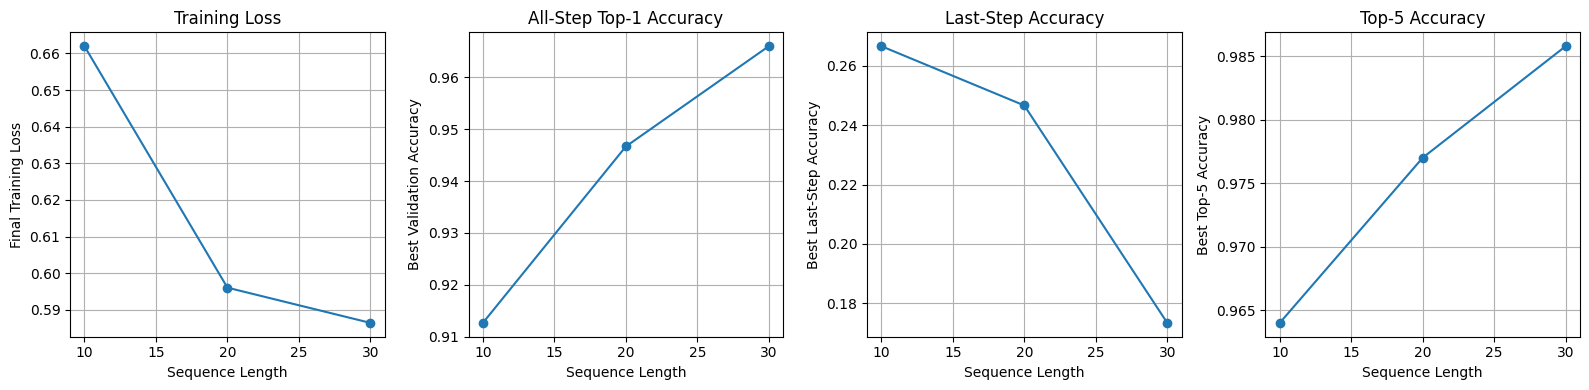

In [41]:
plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.plot(results_df['seq_length'], results_df['train_loss'], marker='o')
plt.xlabel('Sequence Length')
plt.ylabel('Final Training Loss')
plt.title('Training Loss')
plt.grid(True)

plt.subplot(1,4,2)
plt.plot(results_df['seq_length'], results_df['best_val_acc'], marker='o')
plt.xlabel('Sequence Length')
plt.ylabel('Best Validation Accuracy')
plt.title('All-Step Top-1 Accuracy')
plt.grid(True)

plt.subplot(1,4,3)
plt.plot(results_df['seq_length'], results_df['best_last_step_val_acc'], marker='o')
plt.xlabel('Sequence Length')
plt.ylabel('Best Last-Step Accuracy')
plt.title('Last-Step Accuracy')
plt.grid(True)

plt.subplot(1,4,4)
plt.plot(results_df['seq_length'], results_df['best_val_top5_acc'], marker='o')
plt.xlabel('Sequence Length')
plt.ylabel('Best Top-5 Accuracy')
plt.title('Top-5 Accuracy')
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'problem1_transformer_summary.png'), dpi=200, bbox_inches='tight')
plt.show()

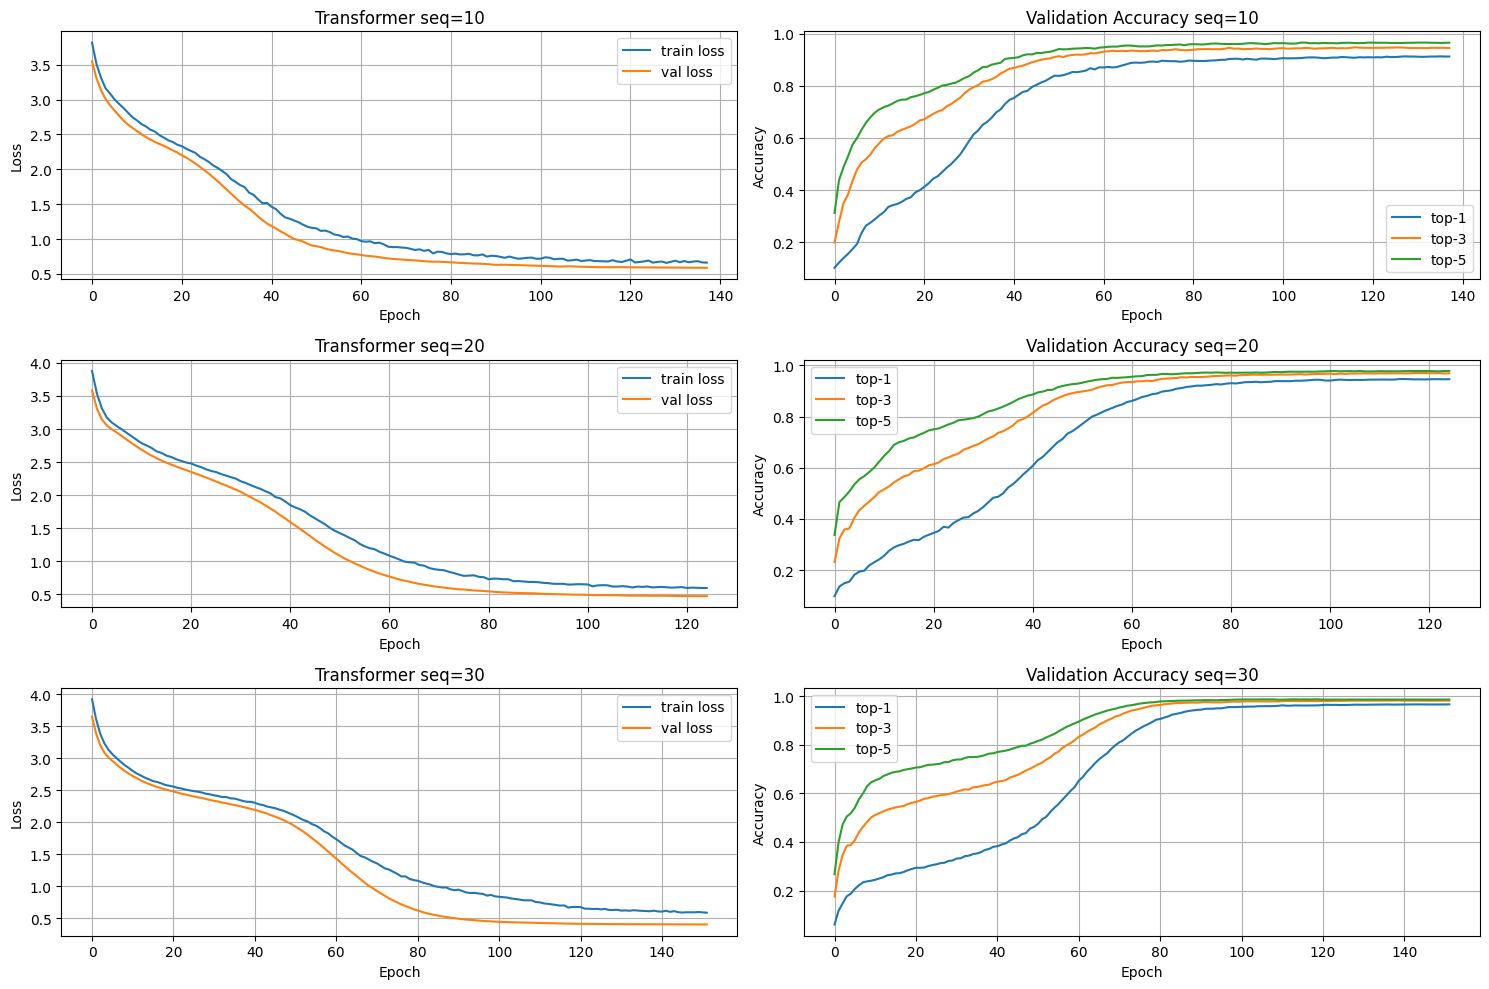

In [42]:
plt.figure(figsize=(15,10))
plot_num = 1
for seq_len in sequence_lengths:
    train_losses, val_losses, val_accs, val_last_accs, val_top3_accs, val_top5_accs = history[seq_len]
    plt.subplot(3,2,plot_num)
    plt.plot(train_losses, label='train loss')
    plt.plot(val_losses, label='val loss')
    plt.title('Transformer seq=' + str(seq_len))
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    plot_num += 1

    plt.subplot(3,2,plot_num)
    plt.plot(val_accs, label='top-1')
    plt.plot(val_top3_accs, label='top-3')
    plt.plot(val_top5_accs, label='top-5')
    plt.title('Validation Accuracy seq=' + str(seq_len))
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend()
    plot_num += 1

plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'problem1_transformer_loss_curves.png'), dpi=200, bbox_inches='tight')
plt.show()

In [43]:
# Compare with Homework 2 RNN/LSTM/GRU results.
hw2_path = os.path.join('..', 'Homework_2', 'Results_Problem_1', 'problem1_results.csv')
if os.path.exists(hw2_path):
    hw2_df = pd.read_csv(hw2_path)
    transformer_compare = results_df.copy()
    transformer_compare['source'] = 'Homework 4 Transformer'
    hw2_compare = hw2_df.copy()
    hw2_compare['source'] = 'Homework 2 RNN based'

    keep_cols = ['source', 'model_type', 'seq_length', 'hidden_size', 'train_loss', 'val_loss',
                 'best_val_acc', 'best_last_step_val_acc', 'best_val_top5_acc',
                 'training_time_sec', 'params', 'model_size_MB', 'rough_complexity']
    compare_df = pd.concat([hw2_compare[keep_cols], transformer_compare[keep_cols]], ignore_index=True)
    compare_df.to_csv(os.path.join(results_folder, 'problem1_transformer_vs_homework2_rnn.csv'), index=False)
    print(compare_df.to_string(index=False))
else:
    print('Homework 2 comparison file was not found:', hw2_path)

                source  model_type  seq_length  hidden_size  train_loss  val_loss  best_val_acc  best_last_step_val_acc  best_val_top5_acc  training_time_sec  params  model_size_MB  rough_complexity
  Homework 2 RNN based         GRU          10          128    1.041658  1.065439      0.772117                0.930818           0.948428          77.200388  110637       0.422047            983040
  Homework 2 RNN based        LSTM          10          128    1.028403  1.077258      0.769182                0.928721           0.947379          75.185652  143661       0.548023           1310720
  Homework 2 RNN based         RNN          10          128    1.154556  1.169113      0.741929                0.911950           0.944235          53.594902   44589       0.170094            327680
  Homework 2 RNN based         GRU          20          128    0.781075  0.756811      0.883053                0.989474           0.974947         185.643758  110637       0.422047           1966080
  Hom

In [44]:
def predict_next_char(model, initial_str, max_length):
    model.eval()
    with torch.no_grad():
        initial_str = initial_str[-max_length:]
        x = torch.tensor([char_to_ix.get(c, char_to_ix[' ']) for c in initial_str], dtype=torch.long).unsqueeze(0).to(device)
        prediction = model(x)
        last_prediction = prediction[:, -1, :]
        predicted_index = torch.argmax(last_prediction, dim=1).item()
        return ix_to_char[predicted_index]


def generate_text(model, start_text, max_length, predict_len=300):
    generated = start_text
    infer_start = time.time()
    for i in range(predict_len):
        generated += predict_next_char(model, generated, max_length)
    return generated, time.time() - infer_start

best_row = results_df.sort_values('best_val_acc', ascending=False).iloc[0]
best_seq = int(best_row['seq_length'])
best_model = trained_models[best_seq]
output_text, inference_time = generate_text(best_model, 'Next character prediction', best_seq, 300)

print('Best Transformer sequence length:', best_seq)
print('Best validation accuracy:', best_row['best_val_acc'])
print('Inference time:', inference_time)
print(output_text)

pd.DataFrame([{
    'best_seq_length': best_seq,
    'best_val_acc': best_row['best_val_acc'],
    'generated_text': output_text,
    'inference_time_sec': inference_time
}]).to_csv(os.path.join(results_folder, 'problem1_generated_text.csv'), index=False)

Best Transformer sequence length: 30
Best validation accuracy: 0.966
Inference time: 0.12486982345581055
Next character predictionnnnnnten n tenentinnnnnntenen tenentinnnnnntenen tenentinnnnnntenen tenentinnnnnntenen tenentinnnnnntenen tenentinnnnnntenen tenentinnnnnntenen tenentinnnnnntenen tenentinnnnnntenen tenentinnnnnntenen tenentinnnnnntenen tenentinnnnnntenen tenentinnnnnntenen tenentinnnnnntenen tenentinnnnnntenen tene
